# Leaky Integrate-and-Fire (LIF) neuron theory

A simple spiking neuron can be modeled with a membrane voltage $v(t)$ that changes over time according to:

$$
\tau_m \frac{dv}{dt} = -(v - V_{rest}) + I(t)
$$

where:
- $\tau_m$ is the membrane time constant
- $V_{rest}$ is the resting potential
- $I(t)$ is the input current

This equation says that the neuron integrates input current while it leaks back toward its resting value. When the voltage reaches a threshold $V_{th}$, the neuron emits a spike and then resets to $V_{reset}$ for a short refractory period $T_{ref}$.

In practice, the discrete-time update is:

$$
v[k] = v[k-1] + \frac{DT}{\tau_m}\left(-(v[k-1] - V_{rest}) + I[k-1]\right)
$$

with the rule:
- if $v[k] \ge V_{th}$: spike occurs, then set $v[k] = V_{reset}$
- during the refractory period, the neuron cannot spike again immediately

This is the core idea behind the simulations below: the neuron charges up with input, leaks back toward rest, spikes when threshold is crossed, and enters a brief reset period.

The code that follows explores:
1. charging without spiking
2. single-neuron spike generation under constant input
3. frequency-current relationship comparing simulation to theory
4. Poisson input driving firing rate output

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
V_REST, V_TH, V_RESET = -52.0, -45.0, -52.0  #mV
TAU_M, T_REF, DT = 20.0, 2.2, 0.1

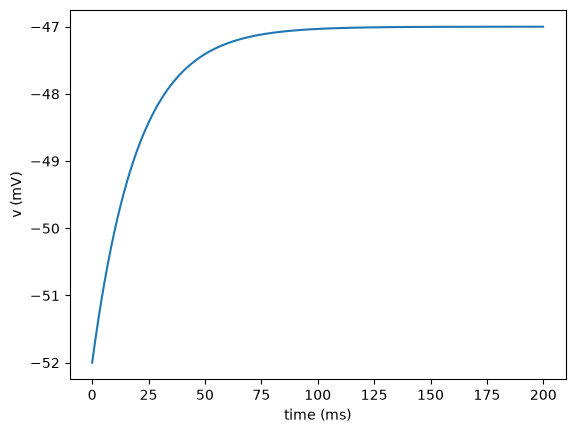

In [5]:
def charge_only(I_mv, T_ms=200.0):
    n = int(T_ms / DT)
    v = np.full(n, V_REST)
    for k in range(1, n):
        v[k] = v[k-1] + DT / TAU_M * (-(v[k-1] - V_REST) + I_mv)
    return np.arange(n) * DT, v

t, v = charge_only(5.0)
plt.plot(t, v); plt.xlabel("time (ms)"); plt.ylabel("v (mV)"); plt.show()

12 spikes


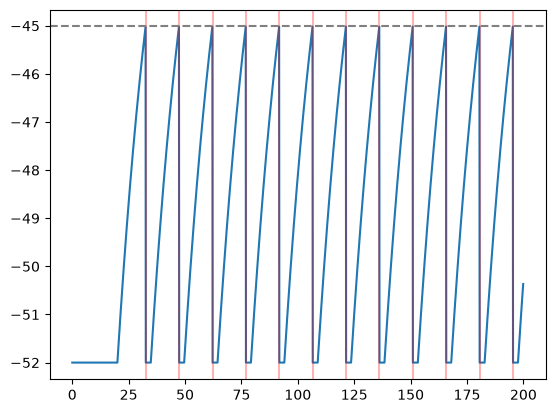

In [6]:
def simulate_lif(I, T_ms=200.0):
    """I: array of input (mV), one value per time step."""
    n = int(T_ms / DT)
    t = np.arange(n) * DT
    v = np.full(n, V_REST)
    spikes, refr = [], 0
    for k in range(1, n):
        if refr > 0:                       # dead time after a spike
            v[k] = V_RESET; refr -= 1
            continue
        v[k] = v[k-1] + DT / TAU_M * (-(v[k-1] - V_REST) + I[k-1])
        if v[k] >= V_TH:                   # comparator trips
            spikes.append(t[k])
            v[k] = V_RESET
            refr = int(round(T_REF / DT))
    return t, v, np.array(spikes)

n = 2000
I = np.zeros(n); I[200:] = 15.0            # input switches on at 20 ms
t, v, s = simulate_lif(I)
print(f"{len(s)} spikes")
plt.plot(t, v)
for x in s: plt.axvline(x, color="red", alpha=0.3)
plt.axhline(V_TH, ls="--", color="gray"); plt.show()

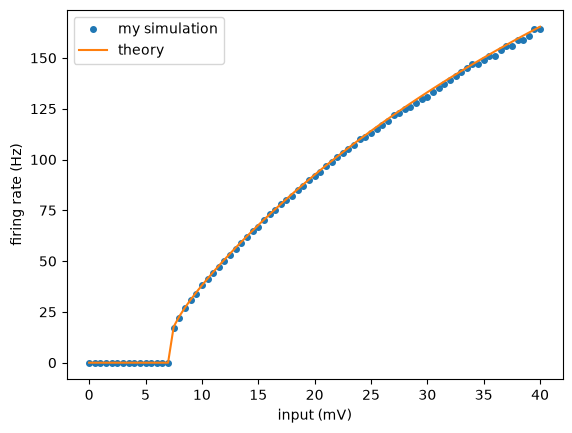

In [7]:
inputs = np.arange(0, 40.5, 0.5)
sim = [len(simulate_lif(np.full(10000, i), T_ms=1000)[2]) for i in inputs]   # spikes in 1 s = Hz
theory = [1000 / (T_REF + TAU_M * np.log(i / (i - 7))) if i > 7 else 0 for i in inputs]

plt.plot(inputs, sim, "o", ms=4, label="my simulation")
plt.plot(inputs, theory, label="theory")
plt.xlabel("input (mV)"); plt.ylabel("firing rate (Hz)"); plt.legend(); plt.show()

In [8]:
def simulate_poisson(rate_hz, kick_mv=2.0, T_ms=1000, seed=0):
    rng = np.random.default_rng(seed)       # same seed -> same result
    n = int(T_ms / DT)
    arrivals = rng.random(n) < rate_hz * DT / 1000
    v, count, refr = V_REST, 0, 0
    for k in range(n):
        if refr > 0: refr -= 1; continue
        v += -(v - V_REST) / TAU_M * DT
        if arrivals[k]: v += kick_mv
        if v >= V_TH:
            count += 1; v = V_RESET; refr = int(round(T_REF / DT))
    return count * 1000 / T_ms              # Hz

for r in (50, 150, 400):
    print(r, "Hz in ->", simulate_poisson(r), "Hz out")

50 Hz in -> 0.0 Hz out
150 Hz in -> 17.0 Hz out
400 Hz in -> 71.0 Hz out
